# Step 3: Preprocessing

Input: `data/raw/quakes_m45_raw.csv` (never edited).
Output: `data/processed/quakes_clean.csv`, `data/processed/quakes_sample.csv`,
figures `figures/step3_*.png`, numbers `results/step3_*.csv`.

Every step records the row count before and after.

In [1]:
import sys
sys.path.append("../scripts")
from config import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import FuncFormatter

# one look for every figure of this step
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 10,
})

for folder in (DATA_PROC, FIGURES_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=FIG_DPI, bbox_inches="tight")
    print("saved", FIGURES_DIR / name)

steps = []  # (step, rows_before, rows_after, note)
def record(step, before, after, note=""):
    steps.append({"step": step, "rows_before": before, "rows_after": after,
                  "rows_removed": before - after, "note": note})
    print(f"{step}: {before:,} -> {after:,} (removed {before - after:,}) {note}")

## 1. Load raw data and fix types

In [2]:
raw = pd.read_csv(RAW_FILE, dtype={"id": str}, encoding="utf-8")
n_raw = len(raw)
print(f"raw: {n_raw:,} rows x {raw.shape[1]} columns")

df = raw.copy()
for col in ("time", "updated"):
    df[col] = pd.to_datetime(df[col], utc=True, format="ISO8601")
print("time range:", df["time"].min(), "..", df["time"].max())
print("unparsed time:", int(df["time"].isna().sum()), "| unparsed updated:", int(df["updated"].isna().sum()))
record("load raw + parse time/updated as UTC", n_raw, len(df))

raw: 187,588 rows x 24 columns


time range: 2000-01-01 01:19:26.990000+00:00 .. 2026-10-10 10:35:11.922000+00:00
unparsed time: 0 | unparsed updated: 0
load raw + parse time/updated as UTC: 187,588 -> 187,588 (removed 0) 


## 2. Missing values

Core columns (time, coordinates, depth, magnitude) must be complete.
The measurement-quality columns are **not imputed**: they are missing by
catalog era and by reporting network, not at random (see the per-year figure).

In [3]:
QUALITY = ["nst", "gap", "dmin", "rms", "horizontalError", "depthError", "magError", "magNst"]
CORE = ["id", "time", "latitude", "longitude", "depth", "mag", "magType"]

missing = (raw.isna().mean() * 100).round(2).rename("pct_missing").to_frame()
missing["n_missing"] = raw.isna().sum()
missing["group"] = ["quality" if c in QUALITY else "core" if c in CORE else "other" for c in missing.index]
missing.index.name = "column"
missing.to_csv(RESULTS_DIR / "step3_missing.csv")
missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)

,pct_missing,n_missing,group
column,,,
horizontalError,51.95,97444,quality
magError,48.80,91546,quality
dmin,48.01,90055,quality
nst,35.91,67367,quality
depthError,29.90,56085,quality
magNst,15.31,28719,quality
gap,9.23,17308,quality
rms,2.60,4877,quality


saved C:\Users\user\AppData\Local\Temp\claude\C--Users-user-Documents-assignment-earthquake-project\92d6d292-728a-47eb-b725-b4f7565b52aa\scratchpad\wt3\figures\step3_missing.png


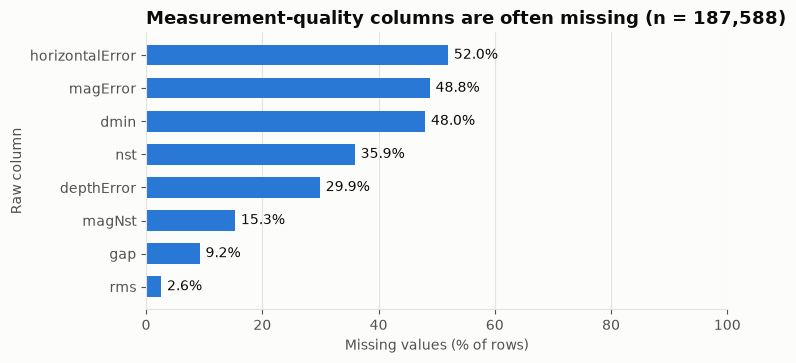

In [4]:
m = missing.loc[QUALITY].sort_values("pct_missing")
fig, ax = plt.subplots(figsize=(7.5, 3.6))
bars = ax.barh(m.index, m["pct_missing"], color=BLUE, height=0.62)
for b, v in zip(bars, m["pct_missing"]):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", color=INK)
ax.set_xlim(0, 100)
ax.set_xlabel("Missing values (% of rows)")
ax.set_ylabel("Raw column")
ax.set_title(f"Measurement-quality columns are often missing (n = {n_raw:,})")
ax.grid(axis="y", visible=False)
save_fig(fig, "step3_missing.png")
plt.show()

saved C:\Users\user\AppData\Local\Temp\claude\C--Users-user-Documents-assignment-earthquake-project\92d6d292-728a-47eb-b725-b4f7565b52aa\scratchpad\wt3\figures\step3_missing_by_year.png


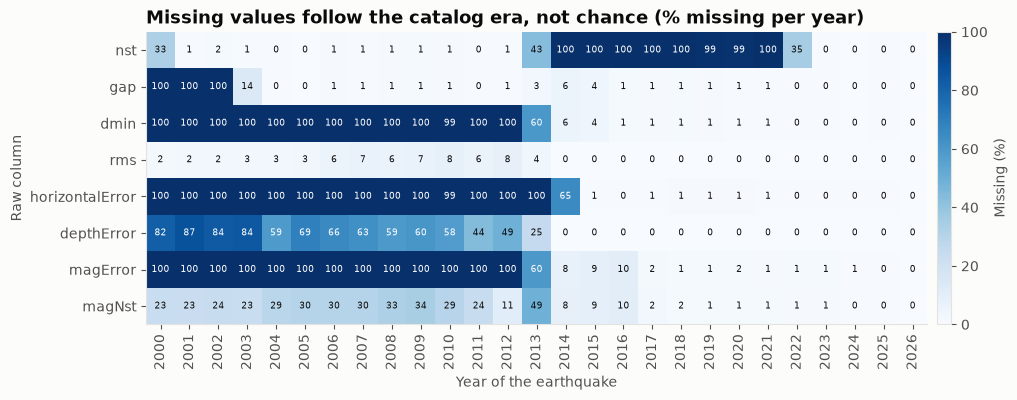

In [5]:
by_year = raw.assign(year=raw["time"].str[:4].astype(int)).groupby("year")[QUALITY] \
             .apply(lambda g: g.isna().mean() * 100).round(1)
by_year.to_csv(RESULTS_DIR / "step3_missing_by_year.csv")

fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(by_year.T.values, aspect="auto", cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(by_year)), by_year.index, rotation=90)
ax.set_yticks(range(len(QUALITY)), QUALITY)
for i in range(len(QUALITY)):
    for j in range(len(by_year)):
        v = by_year.T.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6.5,
                color="white" if v > 55 else INK)
ax.grid(False)
ax.set_xlabel("Year of the earthquake")
ax.set_ylabel("Raw column")
ax.set_title("Missing values follow the catalog era, not chance (% missing per year)")
fig.colorbar(im, ax=ax, label="Missing (%)", pad=0.01)
save_fig(fig, "step3_missing_by_year.png")
plt.show()

## 3. Remove rows that are not usable

Deleted events, non-earthquakes, magnitude below `MIN_MAG` (the update query
asks USGS for M4.0+ to catch downgraded events), rows with a missing core
value, and repeated ids (keep the newest `updated`).

In [6]:
n = len(df); df = df[df["status"] != "deleted"]
record("drop status = deleted", n, len(df))

n = len(df); df = df[df["type"] == "earthquake"]
record("keep type = earthquake", n, len(df))

n = len(df); low = df[df["mag"] < MIN_MAG][["id", "time", "mag", "magType", "place"]]
df = df[df["mag"] >= MIN_MAG]
record(f"keep mag >= {MIN_MAG}", n, len(df))
display(low)

n = len(df); df = df.dropna(subset=CORE)
record("drop rows with a missing core value", n, len(df), "core = " + ", ".join(CORE))

n = len(df); df = df.sort_values("updated").drop_duplicates("id", keep="last")
record("repeated id: keep newest updated", n, len(df))
df = df.sort_values("time").reset_index(drop=True)

drop status = deleted: 187,588 -> 187,588 (removed 0) 
keep type = earthquake: 187,588 -> 187,588 (removed 0) 
keep mag >= 4.5: 187,588 -> 187,584 (removed 4) 


,id,time,mag,magType,place
21944,nc21364840,2004-05-17 21:41:12.700000+00:00,3.38,ml,"12 km NNE of Cayucos, California"
186750,us7000tchn,2026-08-28 05:08:49.255000+00:00,4.40,mb,"56 km S of Hicks Bay, New Zealand"
187093,us7000thlq,2026-09-15 14:16:10.973000+00:00,4.40,mb,"255 km E of Lospalos, Timor Leste"
187094,us7000thn3,2026-09-15 16:12:49.612000+00:00,4.40,mb,"56 km SSW of Bengkulu, Indonesia"


drop rows with a missing core value: 187,584 -> 187,584 (removed 0) core = id, time, latitude, longitude, depth, mag, magType
repeated id: keep newest updated: 187,584 -> 187,584 (removed 0) 


## 4. Same earthquake stored under two ids

USGS sometimes keeps one earthquake under two event ids. Two rows are treated
as the same event when they are at most `DUP_MAX_SEC` seconds and `DUP_MAX_KM`
km apart (haversine distance on the Earth's surface).

**Which row is kept:** the one with the larger magnitude (newest `updated` only
breaks ties). Keeping the newest `updated` instead would delete some of the
largest earthquakes in the catalog, because the small first estimate is often
the row that was edited last. The cell below counts how many.

In [7]:
EARTH_KM = 6371.0088

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_KM * np.arcsin(np.sqrt(a))

t = (df["time"] - pd.Timestamp("1970-01-01", tz="UTC")).dt.total_seconds().to_numpy()   # seconds, rows are sorted by time
# (not astype("int64") / 1e9: pandas 3 may store microseconds, which turns 10 s into 0.01 s)
lat, lon = df["latitude"].to_numpy(), df["longitude"].to_numpy()

pairs = []
k = 1
while True:                                        # compare each row with the k-th next row
    gap = t[k:] - t[:-k]
    idx = np.where(gap <= DUP_MAX_SEC)[0]
    if len(idx) == 0:
        break
    km = haversine_km(lat[idx], lon[idx], lat[idx + k], lon[idx + k])
    pairs += [(i, i + k, g, d) for i, g, d in zip(idx, gap[idx], km) if d <= DUP_MAX_KM]
    k += 1
n_close_in_time = sum(len(np.where(t[j:] - t[:-j] <= DUP_MAX_SEC)[0]) for j in range(1, k))
print(f"pairs within {DUP_MAX_SEC} s: {n_close_in_time:,} | also within {DUP_MAX_KM} km: {len(pairs)}")

# group linked rows (handles chains a-b, b-c)
group = {}
def find(x):
    while group.setdefault(x, x) != x:
        x = group[x]
    return x
for a, b, _, _ in pairs:
    group[find(a)] = find(b)
members = {}
for x in list(group):
    members.setdefault(find(x), []).append(x)

drop_idx, rows = [], []
for g in members.values():
    sub = df.loc[g]
    keep = sub.sort_values(["mag", "updated"]).index[-1]
    newest = sub.sort_values("updated").index[-1]
    for i in g:
        if i == keep:
            continue
        drop_idx.append(i)
        rows.append({
            "time_kept": df.at[keep, "time"], "id_kept": df.at[keep, "id"], "id_dropped": df.at[i, "id"],
            "seconds_apart": round(abs(t[i] - t[keep]), 1),
            "km_apart": round(float(haversine_km(lat[i], lon[i], lat[keep], lon[keep])), 1),
            "mag_kept": df.at[keep, "mag"], "magType_kept": df.at[keep, "magType"],
            "mag_dropped": df.at[i, "mag"], "magType_dropped": df.at[i, "magType"],
            "newest_updated_is_kept": newest == keep, "place": df.at[keep, "place"],
        })
dups = pd.DataFrame(rows).sort_values("time_kept")
dups.to_csv(RESULTS_DIR / "step3_duplicate_pairs.csv", index=False)

other_rule = dups[~dups["newest_updated_is_kept"]]
print(f"duplicate rows dropped: {len(dups)}")
print(f"'keep newest updated' would have kept the smaller row in {len(other_rule)} of them,")
print(f"including {int((other_rule['mag_kept'] >= MAJOR_MAG).sum())} major (M >= {MAJOR_MAG}) earthquakes:")
display(other_rule[other_rule["mag_kept"] >= MAJOR_MAG][["time_kept", "id_kept", "mag_kept", "magType_kept",
                                                           "id_dropped", "mag_dropped", "magType_dropped", "place"]])

n = len(df); df = df.drop(index=drop_idx).reset_index(drop=True)
record(f"same event under two ids (<= {DUP_MAX_SEC} s and <= {DUP_MAX_KM} km): keep larger mag", n, len(df))

pairs within 10 s: 594 | also within 10 km: 37


duplicate rows dropped: 37
'keep newest updated' would have kept the smaller row in 11 of them,
including 3 major (M >= 6.5) earthquakes:


,time_kept,id_kept,mag_kept,magType_kept,id_dropped,mag_dropped,magType_dropped,place
1,2001-01-16 13:25:09.830000+00:00,usp000a7t0,6.9,mwb,usp000a7sz,6.0,mb,"59 km WSW of Bengkulu, Indonesia"
31,2023-04-28 03:13:48.476000+00:00,us7000jwhe,6.6,mww,us7000jwhc,6.0,mb,south of the Fiji Islands
36,2026-03-30 08:44:13.780000+00:00,us7000s8q0,7.3,mww,us7000s8v7,5.4,mb,"51 km ENE of Luganville, Vanuatu"


same event under two ids (<= 10 s and <= 10 km): keep larger mag: 187,584 -> 187,547 (removed 37) 


## 5. Magnitude scales (`magType`)

The catalog mixes many magnitude scales, measured in different ways by
different networks. Only the spelling is cleaned (`Md` and `md` are the same
scale); the magnitudes themselves are not converted.

distinct magType: 22 -> 19 after lower-casing


saved

 C:\Users\user\AppData\Local\Temp\claude\C--Users-user-Documents-assignment-earthquake-project\92d6d292-728a-47eb-b725-b4f7565b52aa\scratchpad\wt3\figures\step3_magtype.png


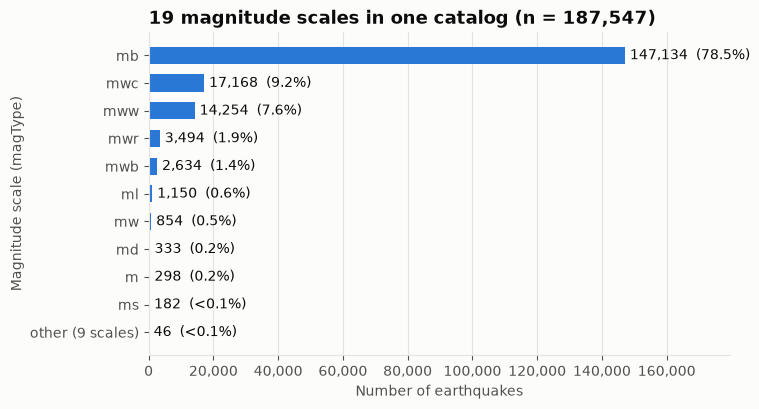

In [8]:
n_types_before = df["magType"].nunique()
df["magType"] = df["magType"].str.strip().str.lower()
mt = df["magType"].value_counts().rename("n").to_frame()
mt["pct"] = (mt["n"] / len(df) * 100).round(3)
mt.index.name = "magType"
mt.to_csv(RESULTS_DIR / "step3_magtype.csv")
print(f"distinct magType: {n_types_before} -> {len(mt)} after lower-casing")

top = mt[mt["n"] >= 100]
rest = mt[mt["n"] < 100]
plot = pd.concat([top["n"], pd.Series({f"other ({len(rest)} scales)": rest["n"].sum()})]).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.barh(plot.index, plot.values, color=BLUE, height=0.62)
for b, v in zip(bars, plot.values):
    ax.text(v + len(df) * 0.008, b.get_y() + b.get_height() / 2,
            f"{v:,}  ({'<0.1' if v / len(df) < 0.001 else f'{v / len(df) * 100:.1f}'}%)", va="center", color=INK)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(0, plot.max() * 1.22)
ax.set_xlabel("Number of earthquakes")
ax.set_ylabel("Magnitude scale (magType)")
ax.set_title(f"{len(mt)} magnitude scales in one catalog (n = {len(df):,})")
ax.grid(axis="y", visible=False)
save_fig(fig, "step3_magtype.png")
plt.show()

## 6. Depths that are a default value, not a measurement

When the depth cannot be resolved it is set to a fixed value. Such values show
up as isolated spikes in the depth histogram. A whole-km depth is flagged as a
default when its count is at least `DEPTH_SPIKE_RATIO` times the median count of
the neighbouring whole-km depths (within 5 km) and at least
`DEPTH_SPIKE_MIN_COUNT` rows. The rows are kept; `depth_fixed` marks them.

In [9]:
counts = df["depth"].value_counts()
whole = counts[counts.index == np.round(counts.index)]
spikes = []
for v, c in whole.items():
    near = [whole.get(float(u), 0) for u in range(int(v) - 5, int(v) + 6) if u != v and u >= 0]
    med = float(np.median(near)) if near else 0.0
    spikes.append({"depth_km": v, "n": int(c), "median_neighbour_n": med, "ratio": round(c / max(med, 1), 1)})
spikes = pd.DataFrame(spikes).sort_values("ratio", ascending=False)
spikes["is_default"] = (spikes["ratio"] >= DEPTH_SPIKE_RATIO) & (spikes["n"] >= DEPTH_SPIKE_MIN_COUNT)
spikes["pct_of_rows"] = (spikes["n"] / len(df) * 100).round(2)
spikes.head(15).to_csv(RESULTS_DIR / "step3_depth_spikes.csv", index=False)

FIXED_DEPTHS = sorted(spikes.loc[spikes["is_default"], "depth_km"])
df["depth_fixed"] = df["depth"].isin(FIXED_DEPTHS)
print("default depth values (km):", FIXED_DEPTHS)
print(f"depth_fixed = True: {int(df['depth_fixed'].sum()):,} rows ({df['depth_fixed'].mean() * 100:.1f}%)")
print("negative depth (above sea level, kept):", int((df["depth"] < 0).sum()))
spikes.head(10)

default depth values (km): [10.0, 30.0, 33.0, 35.0]
depth_fixed = True: 87,087 rows (46.4%)
negative depth (above sea level, kept): 12


,depth_km,n,median_neighbour_n,ratio,is_default,pct_of_rows
0,10.0,64843,238.0,272.4,True,34.57
13,600.0,225,2.0,112.5,False,0.12
1,35.0,11406,124.5,91.6,True,6.08
2,33.0,8455,131.5,64.3,True,4.51
46,500.0,92,2.0,46.0,False,0.05
66,300.0,43,0.0,43.0,False,0.02
88,400.0,30,1.5,20.0,False,0.02
3,30.0,2383,137.0,17.4,True,1.27
61,550.0,49,3.0,16.3,False,0.03
38,200.0,116,7.5,15.5,False,0.06


saved C:\Users\user\AppData\Local\Temp\claude\C--Users-user-Documents-assignment-earthquake-project\92d6d292-728a-47eb-b725-b4f7565b52aa\scratchpad\wt3\figures\step3_depth_fixed.png


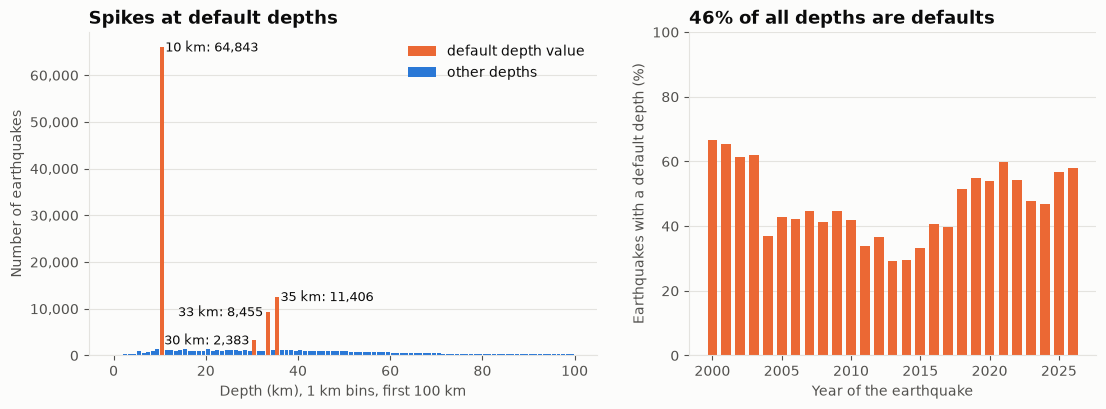

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})

shallow = df[(df["depth"] >= 0) & (df["depth"] < 100)]
edges = np.arange(0, 101, 1)
h, _ = np.histogram(shallow["depth"], bins=edges)
colors = [ORANGE if float(e) in FIXED_DEPTHS else BLUE for e in edges[:-1]]
ax1.bar(edges[:-1] + 0.5, h, width=0.86, color=colors)
for v in FIXED_DEPTHS:
    left = any(v < w <= v + 6 for w in FIXED_DEPTHS)   # label on the left if another spike follows
    ax1.text(v - 0.6 if left else v + 1.2, int(h[int(v)]), f"{v:.0f} km: {int((df['depth'] == v).sum()):,}",
             va="center", ha="right" if left else "left", color=INK, fontsize=9)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax1.set_xlabel("Depth (km), 1 km bins, first 100 km")
ax1.set_ylabel("Number of earthquakes")
ax1.set_title("Spikes at default depths")
ax1.grid(axis="x", visible=False)
ax1.bar([0], [0], color=ORANGE, label="default depth value")
ax1.bar([0], [0], color=BLUE, label="other depths")
ax1.legend(frameon=False, loc="upper right")

share = df.groupby(df["time"].dt.year)["depth_fixed"].mean() * 100
ax2.bar(share.index, share.values, color=ORANGE, width=0.7)
ax2.set_ylim(0, 100)
ax2.set_xlabel("Year of the earthquake")
ax2.set_ylabel("Earthquakes with a default depth (%)")
ax2.set_title(f"{df['depth_fixed'].mean() * 100:.0f}% of all depths are defaults")
ax2.grid(axis="x", visible=False)
save_fig(fig, "step3_depth_fixed.png")
plt.show()

## 7. Region from `place`

`"2 km NE of Satte, Japan"` -> `Japan` (text after the last comma). Places
without a comma are offshore or ocean areas such as `"south of the Fiji
Islands"`; for those the area name is used after removing the direction words.

In [11]:
US_ABBR = {"CA": "California", "AK": "Alaska", "NV": "Nevada", "OR": "Oregon", "MX": "Mexico"}
DIRECTION = (r"^(?:off the (?:\w+ )?coast of|near the (?:\w+ )?coast of|"
             r"(?:north|south|east|west|northeast|northwest|southeast|southwest)(?:ern)? of)\s+(?:the\s+)?")

place = df["place"].fillna("").str.strip()
has_comma = place.str.contains(",")

after_comma = (place.str.rsplit(",", n=1).str[-1].str.strip()
               .str.replace(r"\s+Earthquake$", "", regex=True)
               .str.replace(r"\s+region$", "", regex=True)
               .replace(US_ABBR))
area_name = (place.str.replace(DIRECTION, "", regex=True)
             .str.replace(r"^(?:northern|southern|eastern|western|central)\s+", "", regex=True)
             .str.replace(r"\s+region$", "", regex=True))

df["region"] = np.where(has_comma, after_comma, area_name)
df.loc[df["region"].str.len() == 0, "region"] = np.nan

region_stats = pd.DataFrame([
    {"item": "rows", "value": len(df)},
    {"item": "region from text after last comma", "value": int(has_comma.sum())},
    {"item": "no comma: area name used", "value": int((~has_comma & df["region"].notna()).sum())},
    {"item": "pct without comma", "value": round((~has_comma).mean() * 100, 2)},
    {"item": "region missing", "value": int(df["region"].isna().sum())},
    {"item": "distinct regions", "value": int(df["region"].nunique())},
])
region_stats.to_csv(RESULTS_DIR / "step3_region.csv", index=False)
display(region_stats)
df["region"].value_counts().head(15)

,item,value
0,rows,187547.0
1,region from text after last comma,144045.0
2,no comma: area name used,43502.0
3,pct without comma,23.2
4,region missing,0.0
5,distinct regions,439.0


region
Indonesia                 22784
Japan                     16674
Papua New Guinea          10821
Philippines                9474
Tonga                      8498
Russia                     6774
Chile                      6431
Vanuatu                    5869
Kermadec Islands           5441
South Sandwich Islands     5390
Solomon Islands            4456
Alaska                     4243
New Zealand                4175
Mid-Atlantic Ridge         3820
Fiji                       3738
Name: count, dtype: int64

## 8. Time parts, grid cell and labels

In [12]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["cell_id"] = [cell_id(a, o) for a, o in zip(df["latitude"], df["longitude"])]
df["is_major"] = (df["mag"] >= MAJOR_MAG).astype(int)

lo_mid, lo_deep = DEPTH_BINS["intermediate"][0], DEPTH_BINS["deep"][0]
df["depth_class"] = np.select([df["depth"] < lo_mid, df["depth"] < lo_deep],
                              ["shallow", "intermediate"], default="deep")

print("grid cells with at least one event:", df["cell_id"].nunique())
print(f"is_major = 1: {int(df['is_major'].sum()):,} of {len(df):,} ({df['is_major'].mean() * 100:.2f}%)")
print(df["depth_class"].value_counts().to_string())

grid cells with at least one event: 1206
is_major = 1: 1,218 of 187,547 (0.65%)
depth_class
shallow         148239
intermediate     30621
deep              8687


## 9. Check the agreed columns and save

In [13]:
clean = df[CLEAN_COLUMNS].copy()

assert list(clean.columns) == CLEAN_COLUMNS
assert clean["id"].is_unique
must_be_complete = [c for c in CLEAN_COLUMNS if c not in QUALITY + ["region"]]
assert clean[must_be_complete].notna().all().all(), "a required column has missing values"
assert (clean["mag"] >= MIN_MAG).all()

clean.to_csv(CLEAN_FILE, index=False, encoding="utf-8", date_format="%Y-%m-%dT%H:%M:%S.%fZ")
sample = clean[clean["year"].between(2024, 2025)]
sample.to_csv(SAMPLE_FILE, index=False, encoding="utf-8", date_format="%Y-%m-%dT%H:%M:%S.%fZ")
record("final quakes_clean.csv", n_raw, len(clean), f"{clean.shape[1]} columns")

summary = pd.DataFrame(steps)
summary.to_csv(RESULTS_DIR / "step3_summary.csv", index=False)

facts = pd.DataFrame([
    {"item": "raw rows", "value": n_raw},
    {"item": "clean rows", "value": len(clean)},
    {"item": "rows removed", "value": n_raw - len(clean)},
    {"item": "clean columns", "value": clean.shape[1]},
    {"item": "first event (UTC)", "value": str(clean["time"].min())},
    {"item": "last event (UTC)", "value": str(clean["time"].max())},
    {"item": "is_major rows", "value": int(clean["is_major"].sum())},
    {"item": "is_major pct", "value": round(clean["is_major"].mean() * 100, 3)},
    {"item": "depth_fixed rows", "value": int(clean["depth_fixed"].sum())},
    {"item": "depth_fixed pct", "value": round(clean["depth_fixed"].mean() * 100, 2)},
    {"item": "default depth values (km)", "value": ", ".join(f"{v:.0f}" for v in FIXED_DEPTHS)},
    {"item": "duplicate rows dropped (two ids, one event)", "value": len(dups)},
    {"item": "distinct magType", "value": int(clean["magType"].nunique())},
    {"item": "distinct regions", "value": int(clean["region"].nunique())},
    {"item": "grid cells with events", "value": int(clean["cell_id"].nunique())},
    {"item": "sample rows (2024-2025)", "value": len(sample)},
])
facts.to_csv(RESULTS_DIR / "step3_facts.csv", index=False)
print("saved", CLEAN_FILE, "|", SAMPLE_FILE)
display(summary)
display(facts)

final quakes_clean.csv: 187,588 -> 187,547 (removed 41) 22 columns
saved C:\Users\user\AppData\Local\Temp\claude\C--Users-user-Documents-assignment-earthquake-project\92d6d292-728a-47eb-b725-b4f7565b52aa\scratchpad\wt3\data\processed\quakes_clean.csv | C:\Users\user\AppData\Local\Temp\claude\C--Users-user-Documents-assignment-earthquake-project\92d6d292-728a-47eb-b725-b4f7565b52aa\scratchpad\wt3\data\processed\quakes_sample.csv


,step,rows_before,rows_after,rows_removed,note
0,load raw + parse time/updated as UTC,187588,187588,0,
1,drop status = deleted,187588,187588,0,
2,keep type = earthquake,187588,187588,0,
3,keep mag >= 4.5,187588,187584,4,
4,drop rows with a missing core value,187584,187584,0,"core = id, time, latitude, longitude, depth, m..."
5,repeated id: keep newest updated,187584,187584,0,
6,same event under two ids (<= 10 s and <= 10 km...,187584,187547,37,
7,final quakes_clean.csv,187588,187547,41,22 columns


,item,value
0,raw rows,187588
1,clean rows,187547
2,rows removed,41
3,clean columns,22
4,first event (UTC),2000-01-01 01:19:26.990000+00:00
5,last event (UTC),2026-10-10 10:35:11.922000+00:00
6,is_major rows,1218
7,is_major pct,0.649
8,depth_fixed rows,87087
9,depth_fixed pct,46.43


## 10. Pipeline figure for the slides

saved C:\Users\user\AppData\Local\Temp\claude\C--Users-user-Documents-assignment-earthquake-project\92d6d292-728a-47eb-b725-b4f7565b52aa\scratchpad\wt3\figures\step3_pipeline.png


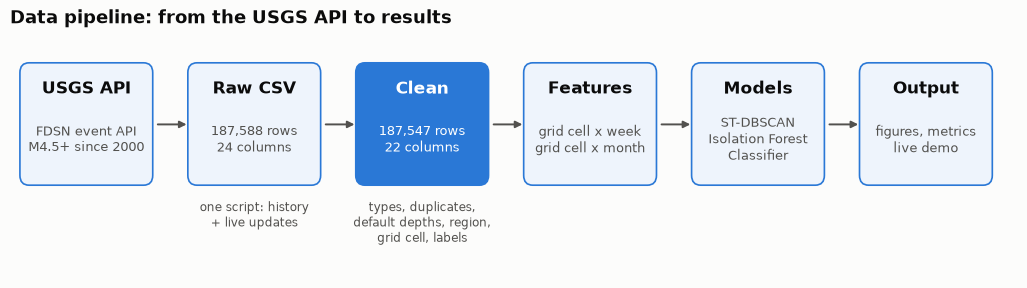

In [14]:
boxes = [
    ("USGS API", "FDSN event API\nM4.5+ since 2000"),
    ("Raw CSV", f"{n_raw:,} rows\n{raw.shape[1]} columns"),
    ("Clean", f"{len(clean):,} rows\n{clean.shape[1]} columns"),
    ("Features", "grid cell x week\ngrid cell x month"),
    ("Models", "ST-DBSCAN\nIsolation Forest\nClassifier"),
    ("Output", "figures, metrics\nlive demo"),
]
notes = ["", "one script: history\n+ live updates",
         "types, duplicates,\ndefault depths, region,\ngrid cell, labels", "", "", ""]

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.set_xlim(0, len(boxes) * 2.2); ax.set_ylim(0, 3); ax.axis("off")
for i, ((title, body), note) in enumerate(zip(boxes, notes)):
    x = 0.15 + i * 2.2
    highlight = title == "Clean"
    ax.add_patch(FancyBboxPatch((x, 1.15), 1.7, 1.45, boxstyle="round,pad=0.02,rounding_size=0.12",
                                facecolor=BLUE if highlight else "#eef4fc", edgecolor=BLUE, linewidth=1.2))
    ax.text(x + 0.85, 2.3, title, ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if highlight else INK)
    ax.text(x + 0.85, 1.68, body, ha="center", va="center", fontsize=9, color="white" if highlight else MUTED)
    ax.text(x + 0.85, 0.95, note, ha="center", va="top", fontsize=8.5, color=MUTED)
    if i < len(boxes) - 1:
        ax.annotate("", xy=(x + 2.2, 1.87), xytext=(x + 1.75, 1.87),
                    arrowprops={"arrowstyle": "-|>", "color": MUTED, "lw": 1.4})
ax.set_title("Data pipeline: from the USGS API to results", loc="left")
save_fig(fig, "step3_pipeline.png")
plt.show()